In [5]:
import torch
import matplotlib.pyplot as plt
from tasks.pendulum import HiddenPendulum

In [6]:
@torch.no_grad()
def rollout_hidden_pendulum_fixed_design(
    experiment,
    theta,
    T=100,
    design_value=-1.0,
    batch_size=1,
    seed=None,
):
    """
    Simule la trajectoire du HiddenPendulum pour un theta fixé
    et un design constant xi_t = design_value.

    Returns:
        dict contenant theta, designs, observations.
    """

    device = experiment.device

    if seed is not None:
        torch.manual_seed(seed)
        if hasattr(experiment.simulator, "generator"):
            experiment.simulator.generator.manual_seed(seed)

    theta = torch.as_tensor(theta, dtype=torch.float32, device=device)

    if theta.ndim == 1:
        theta = theta[None, :]

    if theta.shape[0] == 1 and batch_size > 1:
        theta = theta.repeat(batch_size, 1)

    assert theta.shape == (batch_size, experiment.dim_theta)

    y = experiment.simulator.get_initial_observation(batch_size).to(device)

    designs = []
    observations = []

    for t in range(T):
        xi = torch.full(
            (batch_size, experiment.dim_x),
            fill_value=design_value,
            device=device,
            dtype=torch.float32,
        )

        y = experiment.simulator._sample_outcome(
            theta=theta,
            design=xi,
            last_y=y,
        )

        designs.append(xi.detach().cpu())
        observations.append(y.detach().cpu())

    designs = torch.stack/designs if False else torch.stack(designs, dim=1)
    observations = torch.stack(observations, dim=1)

    return {
        "theta": theta.detach().cpu(),
        "designs": designs,              # [B, T, dim_x]
        "observations": observations,    # [B, T, dim_y]
    }

In [10]:
device = "cpu"

experiment = HiddenPendulum(
    dim_x=1,
    dim_y=2,
    dim_theta=3,
    dt=0.05,
    device=device,
)

theta = torch.tensor([14.7, 0.0, 3.0])

rollout = rollout_hidden_pendulum_fixed_design(
    experiment=experiment,
    theta=theta,
    T=50,
    design_value=-1.0,
    batch_size=1,
    seed=0,
)

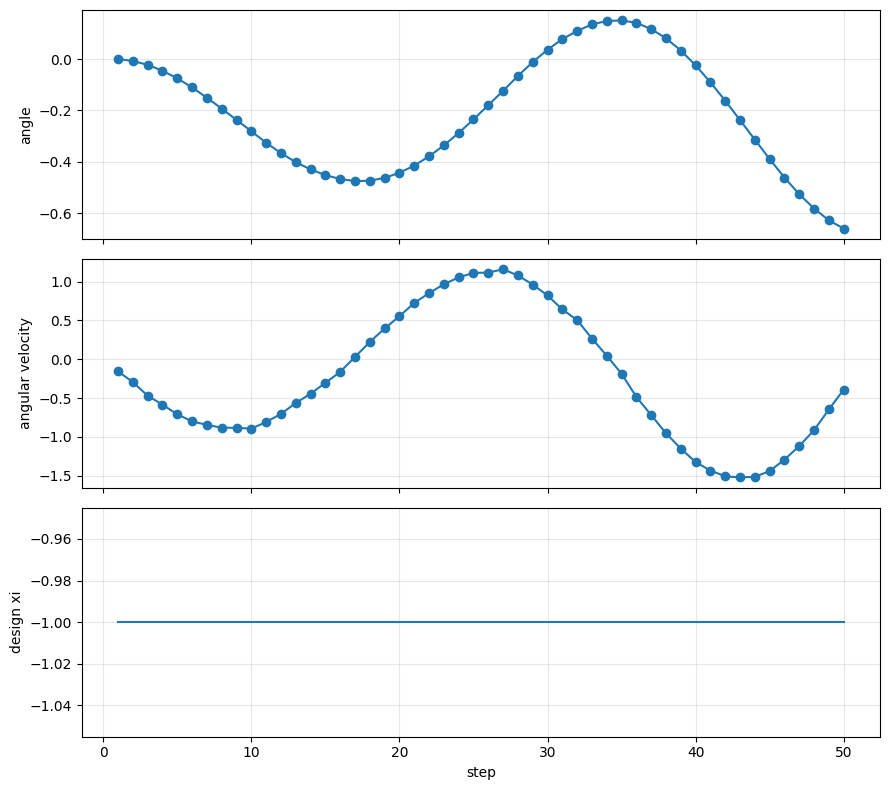

In [11]:
ys = rollout["observations"][0]   # [T, 2]
xis = rollout["designs"][0]       # [T, 1]

angle = ys[:, 0]
velocity = ys[:, 1]
control = xis[:, 0]

t_grid = torch.arange(1, len(angle) + 1)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(t_grid, angle, marker="o")
axes[0].set_ylabel("angle")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_grid, velocity, marker="o")
axes[1].set_ylabel("angular velocity")
axes[1].grid(True, alpha=0.3)

axes[2].step(t_grid, control, where="mid")
axes[2].set_ylabel("design xi")
axes[2].set_xlabel("step")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

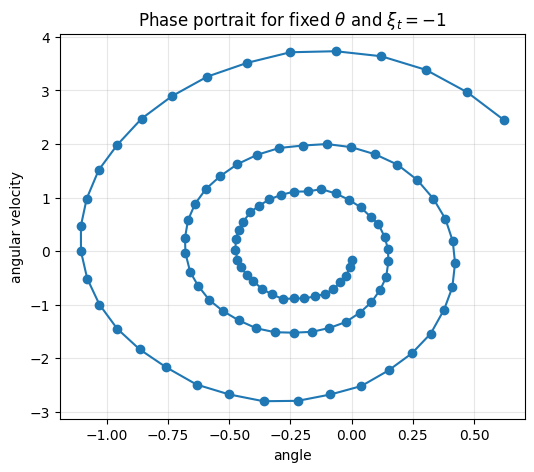

In [9]:
plt.figure(figsize=(6, 5))
plt.plot(angle, velocity, marker="o")
plt.xlabel("angle")
plt.ylabel("angular velocity")
plt.grid(True, alpha=0.3)
plt.title(r"Phase portrait for fixed $\theta$ and $\xi_t=-1$")
plt.show()